# 01 · Exploratory Data Analysis

**Project:** What drives a football player's market value, and which players deviate from it?

**Goal of this notebook**
1. Understand the Transfermarkt tables and how they connect
2. Check data coverage and freshness for our scope (Big 5 leagues, seasons 2024/25 and 2025/26)
3. Define and sanity-check the target variable (market value at season end)
4. Explore first relationships between value and candidate features
5. Collect findings and open decisions for the data pipeline (day 2)

**Scope (from `src/config.py`):** outfield players in the Big 5 leagues with at least 900 league minutes.

## 0. Setup

In [28]:
import os
import sys
from pathlib import Path

# Database path: set TM_DB_PATH only if the file is NOT in data/raw (default location from src/config.py)
# os.environ["TM_DB_PATH"] = r"C:\path\to\transfermarkt-datasets.duckdb"

# Make the project root importable (works when started from /notebooks or the root)
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src import config
from src.db import get_connection, query

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
POSITION_COLORS = {"Attack": "#2a78d6", "Midfield": "#1baf7a", "Defender": "#eb6a2a"}
BASE_COLOR = "#2a78d6"

def save(fig, name):
    """Save a figure to reports/figures for later use in the README."""
    config.FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(config.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

con = get_connection()
LEAGUES = list(config.TOP5_LEAGUES)
SEASONS = config.SEASONS
print("Connected to", config.DB_PATH)

Connected to C:\Users\Alexa\Projects\football-player-valuation\data\raw\transfermarkt-datasets.duckdb


## 1. Table overview
The database contains 12 joinable tables. For this project the most relevant ones are
`players`, `player_valuations`, `appearances`, `games`, `competitions` and `clubs`.

In [29]:
tables = query(con, "SHOW TABLES")["name"].tolist()
row_counts = pd.DataFrame(
    [(t, con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]) for t in tables],
    columns=["table", "rows"],
).sort_values("rows", ascending=False)
row_counts

,table,rows
6,game_lineups,3179016
0,appearances,1894350
5,game_events,1274469
9,player_valuations,656301
1,club_games,177916
11,transfers,175165
7,games,88958
10,players,50149
2,clubs,796
8,national_teams,124


### Schemas of the core tables

In [30]:
for t in ["players", "player_valuations", "appearances", "games"]:
    print(f"\n=== {t}")
    display(query(con, f"DESCRIBE {t}")[["column_name", "column_type"]].T)


=== players


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
column_name,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
column_type,INTEGER,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,TIMESTAMP,VARCHAR,VARCHAR,VARCHAR,INTEGER,TIMESTAMP,VARCHAR,VARCHAR,INTEGER,INTEGER,VARCHAR,VARCHAR,VARCHAR,VARCHAR,INTEGER,INTEGER



=== player_valuations


,0,1,2,3,4,5
column_name,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
column_type,INTEGER,DATE,INTEGER,VARCHAR,INTEGER,VARCHAR



=== appearances


,0,1,2,3,4,5,6,7,8,9,10,11,12
column_name,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
column_type,VARCHAR,INTEGER,INTEGER,INTEGER,VARCHAR,DATE,VARCHAR,VARCHAR,INTEGER,INTEGER,INTEGER,INTEGER,INTEGER



=== games


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
column_name,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,away_club_position,home_club_manager_name,away_club_manager_name,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
column_type,VARCHAR,VARCHAR,VARCHAR,VARCHAR,DATE,INTEGER,INTEGER,INTEGER,INTEGER,INTEGER,INTEGER,VARCHAR,VARCHAR,VARCHAR,INTEGER,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR,VARCHAR


In [31]:
query(con, "SELECT * FROM players LIMIT 3")

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09,Centre-Forward,Attack,right,184,NaT,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000,30000000
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06,Goalkeeper,Goalkeeper,left,190,NaT,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000,8000000
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30,Centre-Forward,Attack,None,<NA>,NaT,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,<NA>,<NA>,None,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000,34500000


## 2. Data freshness
The upstream pipeline stopped in July 2026. We verify the last available date per table,
since it determines which seasons we can use and where the target cutoff must sit.

In [32]:
query(con, """
    SELECT 'games' AS tbl, MIN(date) AS first_date, MAX(date) AS last_date FROM games
    UNION ALL SELECT 'appearances', MIN(date), MAX(date) FROM appearances
    UNION ALL SELECT 'player_valuations', MIN(date), MAX(date) FROM player_valuations
""")

,tbl,first_date,last_date
0,games,2006-06-09,2026-07-06
1,appearances,2012-07-03,2026-06-28
2,player_valuations,2000-01-20,2026-06-12


## 3. Scope check: Big 5 leagues and season coverage
A complete season has 380 games (20 teams) or 306 games (18 teams: Bundesliga, Ligue 1).

In [33]:
query(con, "SELECT competition_id, name, country_name, type FROM competitions WHERE competition_id IN ?", [LEAGUES])

,competition_id,name,country_name,type
0,ES1,laliga,Spain,domestic_league
1,FR1,ligue-1,France,domestic_league
2,GB1,premier-league,England,domestic_league
3,IT1,serie-a,Italy,domestic_league
4,L1,bundesliga,Germany,domestic_league


In [34]:
coverage = query(con, """
    SELECT competition_id,
           CAST(season AS INTEGER) AS season,
           COUNT(*)  AS n_games,
           MIN(date) AS first_game,
           MAX(date) AS last_game
    FROM games
    WHERE competition_id IN ? AND CAST(season AS INTEGER) BETWEEN 2022 AND 2025
    GROUP BY 1, 2
    ORDER BY 1, 2
""", [LEAGUES])
coverage.pivot(index="competition_id", columns="season", values="n_games")

season,2022,2023,2024,2025
competition_id,,,,
ES1,380,380,380,380
FR1,380,306,306,306
GB1,380,380,380,380
IT1,380,380,380,380
L1,306,306,306,306


## 4. Player-season sample
We aggregate league appearances to one row per player, season and league.
Players who switched between two Big 5 leagues mid-season appear twice; we count how often that happens.

In [35]:
PLAYER_SEASON_SQL = """
    SELECT a.player_id,
           CAST(g.season AS INTEGER) AS season,
           a.competition_id          AS league,
           COUNT(*)                  AS appearances,
           SUM(a.minutes_played)     AS minutes,
           SUM(a.goals)              AS goals,
           SUM(a.assists)            AS assists,
           SUM(a.yellow_cards)       AS yellow_cards,
           SUM(a.red_cards)          AS red_cards
    FROM appearances a
    JOIN games g USING (game_id)
    WHERE a.competition_id IN ? AND CAST(g.season AS INTEGER) IN ?
    GROUP BY 1, 2, 3
"""
player_seasons = query(con, PLAYER_SEASON_SQL, [LEAGUES, SEASONS])
print(f"{len(player_seasons):,} player-season-league rows")

dupes = player_seasons.groupby(["player_id", "season"]).size()
print(f"{(dupes > 1).sum():,} player-seasons split across two Big 5 leagues")

5,539 player-season-league rows
147 player-seasons split across two Big 5 leagues


In [36]:
# Add profile attributes from the players table
profile = query(con, """
    SELECT player_id, name, position, sub_position, foot, height_in_cm,
           date_of_birth, contract_expiration_date, international_caps,
           country_of_citizenship
    FROM players
""")
ps = player_seasons.merge(profile, on="player_id", how="left")

# Age at the middle of the season (1 January)
mid_season = pd.to_datetime((ps["season"] + 1).astype(str) + "-01-01")
ps["age"] = (mid_season - pd.to_datetime(ps["date_of_birth"])).dt.days / 365.25

ps["position"].value_counts(dropna=False)

position
Defender      1904
Attack        1638
Midfield      1594
Goalkeeper     403
Name: count, dtype: int64

### Minutes distribution and the 900-minute threshold

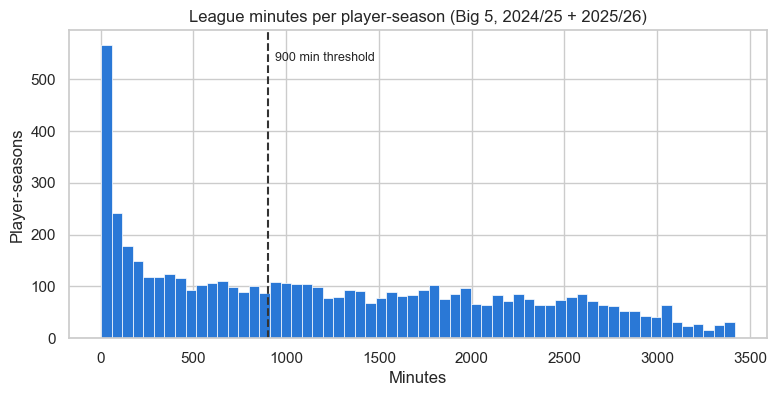

Rows after filters: 2,925 of 5,539


season,2024,2025,All
league,,,
ES1,316,323,639
FR1,265,256,521
GB1,295,316,611
IT1,320,313,633
L1,257,264,521
All,1453,1472,2925


In [37]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ps["minutes"], bins=60, color=BASE_COLOR, edgecolor="white", linewidth=0.5)
ax.axvline(config.MIN_MINUTES, color="#333333", linestyle="--", linewidth=1.5)
ax.text(config.MIN_MINUTES + 40, ax.get_ylim()[1] * 0.9, f"{config.MIN_MINUTES} min threshold", fontsize=9)
ax.set(title="League minutes per player-season (Big 5, 2024/25 + 2025/26)", xlabel="Minutes", ylabel="Player-seasons")
save(fig, "01_minutes_distribution")
plt.show()

sample = ps[(ps["minutes"] >= config.MIN_MINUTES) & (~ps["position"].isin(config.EXCLUDED_POSITIONS))]
print(f"Rows after filters: {len(sample):,} of {len(ps):,}")
sample.pivot_table(index="league", columns="season", values="player_id", aggfunc="count", margins=True)

## 5. Target variable: market value at season end
Transfermarkt updates values irregularly (typically a few times per year). We take the **latest valuation
on or before the cutoff date** (mid-June after the season) using a DuckDB `ASOF JOIN`,
and check how old that valuation is.

In [38]:
valuation_updates = query(con, """
    SELECT YEAR(date) AS year, COUNT(*) AS n_valuations, COUNT(DISTINCT player_id) AS n_players
    FROM player_valuations
    WHERE YEAR(date) >= 2020
    GROUP BY 1 ORDER BY 1
""")
valuation_updates["updates_per_player"] = valuation_updates["n_valuations"] / valuation_updates["n_players"]
valuation_updates

,year,n_valuations,n_players,updates_per_player
0,2020,48749,22807,2.14
1,2021,58412,25650,2.28
2,2022,59564,26848,2.22
3,2023,57576,27890,2.06
4,2024,45376,19628,2.31
5,2025,45482,18951,2.40
6,2026,20852,16711,1.25


In [39]:
keys = sample[["player_id", "season"]].drop_duplicates().copy()
keys["cutoff"] = pd.to_datetime(keys["season"].map(config.season_cutoff))
con.register("keys_df", keys)

target = query(con, """
    SELECT k.player_id, k.season, k.cutoff,
           v.date                AS valuation_date,
           v.market_value_in_eur AS market_value
    FROM keys_df k
    ASOF LEFT JOIN player_valuations v
      ON k.player_id = v.player_id AND k.cutoff >= v.date
""")
target["valuation_age_days"] = (target["cutoff"] - pd.to_datetime(target["valuation_date"])).dt.days

print("Missing target:", target["market_value"].isna().sum())
print(f"Stale (> {config.MAX_VALUATION_AGE_DAYS} days):",
      (target["valuation_age_days"] > config.MAX_VALUATION_AGE_DAYS).sum())
target.groupby("season")["valuation_age_days"].describe(percentiles=[0.5, 0.9])

Missing target: 6
Stale (> 180 days): 59


,count,mean,std,min,50%,90%,max
season,,,,,,,
2024,"1,439.00",56.09,108.04,6.00,12.00,179.00,745.00
2025,"1,471.00",14.77,19.16,10.00,14.00,19.00,738.00


In [40]:
df = sample.merge(target[["player_id", "season", "market_value", "valuation_age_days"]],
                  on=["player_id", "season"], how="left")
df = df[df["market_value"].notna() & (df["market_value"] > 0)].copy()
df["log_value"] = np.log(df["market_value"])
df["season_label"] = df["season"].map(config.season_label)

df.groupby("season_label")["market_value"].describe(percentiles=[0.1, 0.5, 0.9]).map(lambda x: f"{x:,.0f}")

,count,mean,std,min,10%,50%,90%,max
season_label,,,,,,,,
2024/25,"1,447","16,914,547","21,981,244","300,000","1,800,000","9,000,000","40,000,000","200,000,000"
2025/26,"1,472","18,118,139","22,138,161","100,000","2,000,000","10,000,000","40,000,000","200,000,000"


### Why we model log(market value)

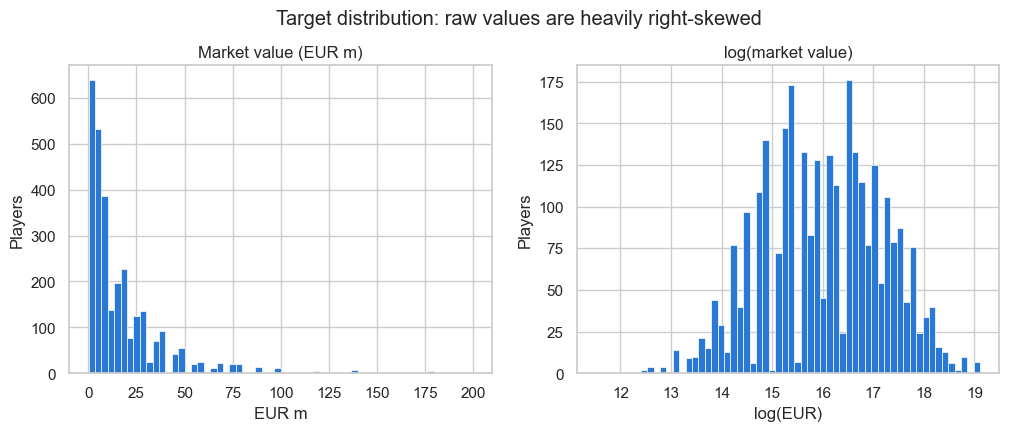

Skewness raw: 3.12 | log: -0.16


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["market_value"] / 1e6, bins=60, color=BASE_COLOR, edgecolor="white", linewidth=0.5)
axes[0].set(title="Market value (EUR m)", xlabel="EUR m", ylabel="Players")
axes[1].hist(df["log_value"], bins=60, color=BASE_COLOR, edgecolor="white", linewidth=0.5)
axes[1].set(title="log(market value)", xlabel="log(EUR)", ylabel="Players")
fig.suptitle("Target distribution: raw values are heavily right-skewed", y=1.02)
save(fig, "02_target_distribution")
plt.show()
print(f"Skewness raw: {df['market_value'].skew():.2f} | log: {df['log_value'].skew():.2f}")

## 6. Data quality of profile features

In [42]:
profile_cols = ["position", "sub_position", "foot", "height_in_cm", "date_of_birth",
                "contract_expiration_date", "international_caps"]
(df[profile_cols].isna().mean() * 100).round(1).rename("missing_%").to_frame()

,missing_%
position,0.00
sub_position,0.00
foot,0.10
height_in_cm,0.00
date_of_birth,0.00
contract_expiration_date,8.70
international_caps,9.30


**Caveat: `players` is a snapshot, not a history.** `contract_expiration_date` reflects the contract as of the
last scrape (mid 2026). For the 2024/25 season this can include renewals signed later, which leaks future
information. We quantify how often the stored contract ends before the season cutoff (a sign of an outdated
or already expired contract) versus far in the future.

In [43]:
contract = pd.to_datetime(df["contract_expiration_date"])
cutoff = pd.to_datetime(df["season"].map(config.season_cutoff))
df["contract_months_left"] = (contract - cutoff).dt.days / 30.44

df.groupby("season_label")["contract_months_left"].describe(percentiles=[0.1, 0.5, 0.9])

,count,mean,std,min,10%,50%,90%,max
season_label,,,,,,,,
2024/25,"1,309.00",41.51,15.89,12.48,24.47,36.50,60.48,120.47
2025/26,"1,355.00",32.18,15.44,0.49,12.48,36.50,48.49,108.48


## 7. First relationships

### Age curve by position

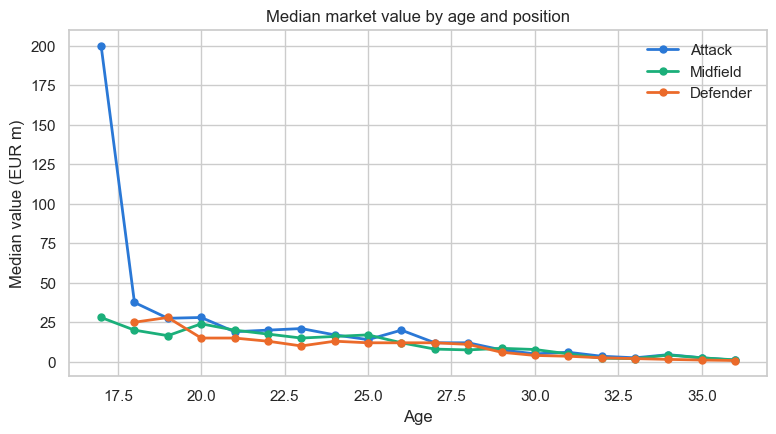

In [44]:
df["age_bin"] = df["age"].round().clip(17, 36)
curve = df.groupby(["position", "age_bin"])["market_value"].median().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
for pos, color in POSITION_COLORS.items():
    d = curve[curve["position"] == pos]
    ax.plot(d["age_bin"], d["market_value"] / 1e6, color=color, linewidth=2, marker="o", markersize=5, label=pos)
ax.set(title="Median market value by age and position", xlabel="Age", ylabel="Median value (EUR m)")
ax.legend(frameon=False)
save(fig, "03_age_curve")
plt.show()

### Value by league

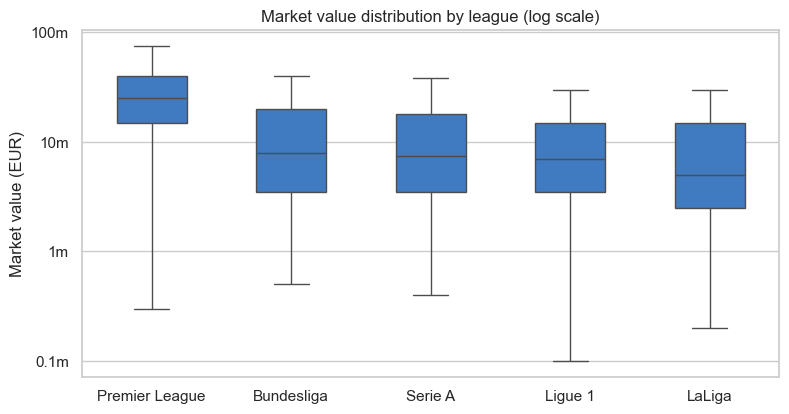

In [45]:
df["league_name"] = df["league"].map(config.TOP5_LEAGUES)
order = df.groupby("league_name")["market_value"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="league_name", y="market_value", order=order, color=BASE_COLOR,
            showfliers=False, width=0.5, ax=ax)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:g}m"))
ax.set(title="Market value distribution by league (log scale)", xlabel="", ylabel="Market value (EUR)")
save(fig, "04_value_by_league")
plt.show()

### Playing time and output vs. value

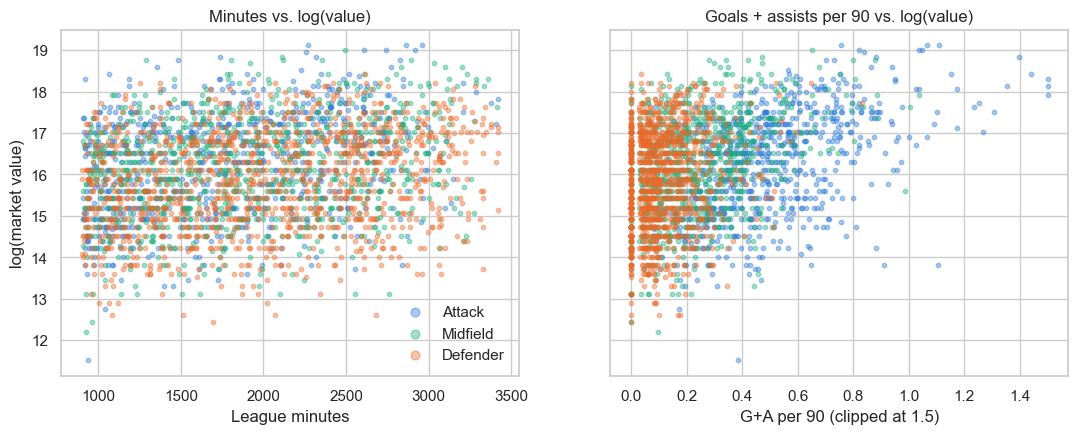

In [46]:
df["goal_contrib_p90"] = (df["goals"] + df["assists"]) / df["minutes"] * 90

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for pos, color in POSITION_COLORS.items():
    d = df[df["position"] == pos]
    axes[0].scatter(d["minutes"], d["log_value"], s=10, alpha=0.4, color=color, label=pos)
    axes[1].scatter(d["goal_contrib_p90"].clip(upper=1.5), d["log_value"], s=10, alpha=0.4, color=color)
axes[0].set(title="Minutes vs. log(value)", xlabel="League minutes", ylabel="log(market value)")
axes[1].set(title="Goals + assists per 90 vs. log(value)", xlabel="G+A per 90 (clipped at 1.5)")
axes[0].legend(frameon=False, markerscale=2)
save(fig, "05_performance_vs_value")
plt.show()

### Correlation of numeric candidates with log(value)

In [47]:
num_cols = ["age", "minutes", "appearances", "goals", "assists", "goal_contrib_p90",
            "yellow_cards", "height_in_cm", "international_caps", "contract_months_left"]
corr = df[num_cols + ["log_value"]].corr(method="spearman")["log_value"].drop("log_value")
corr.sort_values(ascending=False).to_frame("spearman_rho")

,spearman_rho
contract_months_left,0.44
goals,0.33
assists,0.31
goal_contrib_p90,0.30
minutes,0.23
appearances,0.21
international_caps,0.19
yellow_cards,0.01
height_in_cm,0.00
age,-0.46


### Most valuable players in the sample (sanity check)

In [48]:
(df.sort_values("market_value", ascending=False)
   [["name", "season_label", "league", "position", "age", "minutes", "goals", "assists", "market_value"]]
   .head(15))

,name,season_label,league,position,age,minutes,goals,assists,market_value
991,Lamine Yamal,2024/25,ES1,Attack,17.47,"2,864.00",9.00,15.00,200000000
957,Erling Haaland,2025/26,GB1,Attack,25.45,"2,959.00",27.00,8.00,200000000
1919,Lamine Yamal,2025/26,ES1,Attack,18.47,"2,270.00",16.00,12.00,200000000
1008,Kylian Mbappé,2024/25,ES1,Attack,26.03,"2,917.00",31.00,3.00,180000000
2811,Kylian Mbappé,2025/26,ES1,Attack,27.03,"2,606.00",25.00,5.00,180000000
2851,Erling Haaland,2024/25,GB1,Attack,24.45,"2,743.00",22.00,3.00,180000000
2341,Jude Bellingham,2024/25,ES1,Midfield,21.51,"2,493.00",9.00,9.00,180000000
464,Vinicius Junior,2024/25,ES1,Attack,24.47,"2,258.00",11.00,10.00,170000000
1367,Bukayo Saka,2024/25,GB1,Attack,23.32,"1,736.00",6.00,11.00,150000000
1338,Michael Olise,2025/26,L1,Attack,24.05,"2,320.00",15.00,21.00,150000000


## 8. Findings and open decisions
*Filled in on 2026-09-30 from a full run of this notebook.*

**Coverage**
- [x] Are both seasons complete for all five leagues (see section 3)? **Yes.** 380 games (GB1, ES1, IT1) and
  306 games (L1, FR1) in both 2024/25 and 2025/26; last 2025/26 games on 2026-05-16 to 2026-05-24.
- [x] Sample size after filters per season: **1,453 (2024/25) and 1,472 (2025/26)**, 2,925 rows in total.
  These are player-season-league rows; after summing mid-season movers (day 2) it is 1,455 and 1,483 player-seasons.

**Target**
- [x] Median valuation age at cutoff, share of stale valuations: median **12 days (2024/25)** and **14 days (2025/26)**,
  but the seasons are asymmetric: 2024/25 has 16.0% of valuations older than 90 days (Dec 2024 / Mar 2025 update rounds)
  and 58 older than 180 days; 2025/26 has 0.1% older than 90 days and 1 older than 180 days. 6 players without any valuation.
- [x] Decision: **drop valuations older than 180 days** (`config.MAX_VALUATION_AGE_DAYS`, 59 rows, about 2%) and
  players without a valuation. Keep 90-180 days (dropping them would remove 16% of 2024/25, likely skewed towards
  lesser-known players). Cutoff stays at 06-15 for both seasons. The 2024/25 vs 2025/26 asymmetry is a README limitation.

**Features**
- [x] Strongest raw correlations with log(value) (Spearman): age -0.46, contract_months_left +0.44, goals +0.33,
  assists +0.31, goal contributions p90 +0.30, minutes +0.23. Height and yellow cards about 0.
  Target skewness: raw 3.12, log -0.16, so log(value) is the right target.
- [x] Decision on `contract_months_left`: **dropped from the main model** (snapshot leakage for 2024/25).
  A comparison model with contract length is trained on day 3; the exclusion is listed as a README limitation.
  Evidence: the high correlation (+0.44) is not usable signal. The key mechanism (final contract year lowers value)
  is missing from the data: 0.0% of 2024/25 players show < 12 months left (min 12.5 months), 0.4% in 2025/26,
  versus an estimated 15-20% in reality (rough benchmark, not measured here). Expired contracts were overwritten by renewals or new clubs' contracts, so
  the feature mostly proxies "good players get long extensions" (reverse causality plus future information).
- [x] Players split across two leagues: **one row per player-season**, stats summed across leagues,
  `league` = league with most minutes, flag `mid_season_transfer` from `transfers`. Fees not used as features.

**Next step (day 2):** move the SQL from this notebook into `src/build_dataset.py` and add team strength,
European minutes and previous-season features.

In [49]:
con.close()